In [1]:
!pip install tifffile matplotlib opencv-python lxml imagecodecs

In [2]:
import os
import cv2
import numpy as np
import tifffile as tiff
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

In [3]:
def xml_to_mask(xml_path, image_shape):
    mask = np.zeros(image_shape[:2], dtype=np.uint8)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for region in root.iter('Region'):
        coords = []
        
        for vertex in region.iter('Vertex'):
            x = float(vertex.attrib['X'])
            y = float(vertex.attrib['Y'])
            coords.append([int(x), int(y)])
        
        coords = np.array(coords, dtype=np.int32)
        
        # Preenche o polígono na máscara
        cv2.fillPoly(mask, [coords], 1)

    return mask

In [4]:
def visualize_sample(image_path, xml_path):
    # carregar imagem
    image = tiff.imread(image_path)

    # gerar máscara
    mask = xml_to_mask(xml_path, image.shape)

    # plot
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Imagem")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Ground Truth (Mask)")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(image)
    plt.imshow(mask, cmap="jet", alpha=0.4)
    plt.axis("off")

    plt.show()

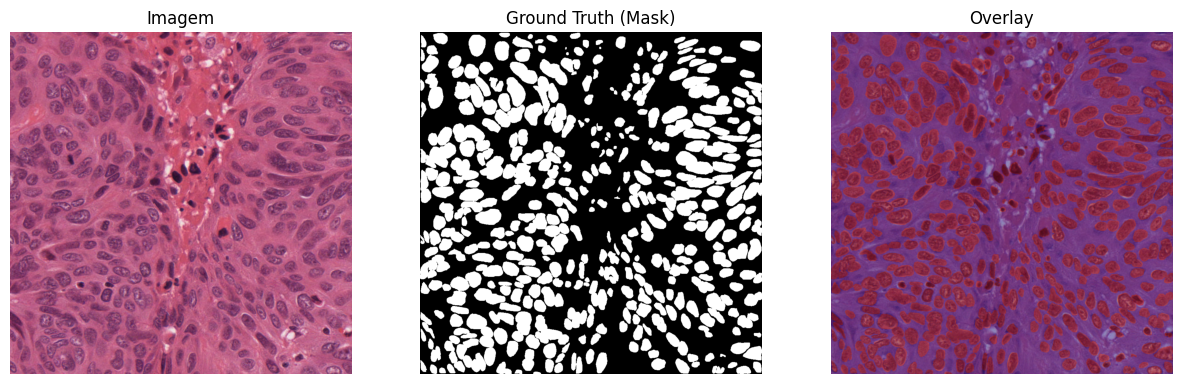

In [6]:
image_path = "TCGA-18-5592-01Z-00-DX1.tif"
xml_path   = "TCGA-18-5592-01Z-00-DX1.xml"

visualize_sample(image_path, xml_path)

In [7]:
pred_path = "TCGA-18-5592-01Z-00-DX1_masks.tif"

In [8]:
image = tiff.imread(image_path)
gt_mask = xml_to_mask(xml_path, image.shape)
pred_mask = tiff.imread(pred_path)

# converter para binário
gt_bin = (gt_mask > 0).astype(np.uint8)
pred_bin = (pred_mask > 0).astype(np.uint8)

In [9]:
import matplotlib.pyplot as plt

def overlay_masks(image, gt, pred):
    plt.figure(figsize=(15,5))

    # imagem original
    plt.subplot(1,3,1)
    plt.title("Imagem")
    plt.imshow(image)
    plt.axis("off")

    # GT
    plt.subplot(1,3,2)
    plt.title("Ground Truth (verde)")
    plt.imshow(image)
    plt.imshow(gt, cmap='Greens', alpha=0.4)
    plt.axis("off")

    # Predição
    plt.subplot(1,3,3)
    plt.title("Predição (vermelho)")
    plt.imshow(image)
    plt.imshow(pred, cmap='Reds', alpha=0.4)
    plt.axis("off")

    plt.show()

In [13]:
def overlay_comparison(image, gt, pred):
    plt.figure(figsize=(6,6))
    plt.imshow(image)

    # regiões
    tp = (gt == 1) & (pred == 1)
    fp = (pred == 1) & (gt == 0)
    fn = (gt == 1) & (pred == 0)

    # cores separadas
    plt.imshow(tp, cmap='gray', alpha=0.3)   # acerto (neutro)
    plt.imshow(fp, cmap='Reds', alpha=0.6)   # falso positivo
    plt.imshow(fn, cmap='Blues', alpha=0.6)  # falso negativo

    plt.title("Vermelho = FP | Azul = FN")
    plt.axis("off")
    plt.show()

    

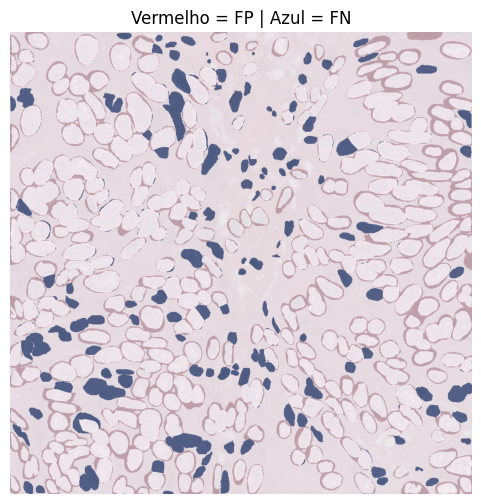

In [14]:
overlay_comparison(image, gt_bin, pred_bin)

In [5]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

loading images


NameError: name 'trange' is not defined